In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Employees plan
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/raw/3328_wahetnoor'))
csv_file = 'Employee Plans.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df_plans = pd.read_csv(absolute_path)
print(df_plans.head(3))

   TenantId      Id                 FromDate                   ToDate  \
0      3328  157797  2023-08-26 00:00:00.000  2024-07-26 20:48:30.457   
1      3328  179508  2024-02-07 00:00:00.000  2025-12-25 00:00:00.000   
2      3328  157801  2023-08-26 00:00:00.000  2025-12-25 00:00:00.000   

   EmployeeId  PlanId  
0       47834    4359  
1       47834    4430  
2       47835    4358  


In [3]:
#Load the Transormed Data
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3328_wahetnoor'))
csv_file = '3228_wahetnoor_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df = pd.read_csv(absolute_path)

# Merge the datasets on 'EmployeeId'
merged_df = pd.merge(df, df_plans[['EmployeeId', 'PlanId']], on='EmployeeId', how='inner')
print(merged_df.head(10))


   EmployeeId   Transdate  DayOfWeek CheckInTime CheckOutTime      hours  \
0       47834  2023-09-20          1    12:11:00     15:14:00   3.050000   
1       47834  2023-09-20          1    12:11:00     15:14:00   3.050000   
2       47834  2023-10-01          2    06:00:00     16:46:00  10.766667   
3       47834  2023-10-01          2    06:00:00     16:46:00  10.766667   
4       47834  2023-10-02          3    08:56:00     15:36:00   6.666667   
5       47834  2023-10-02          3    08:56:00     15:36:00   6.666667   
6       47834  2023-10-03          3    09:19:00     14:08:00   4.816667   
7       47834  2023-10-03          3    09:19:00     14:08:00   4.816667   
8       47834  2023-10-04          0    09:11:00     15:32:00   6.350000   
9       47834  2023-10-04          0    09:11:00     15:32:00   6.350000   

   PlanId  
0    4359  
1    4430  
2    4359  
3    4430  
4    4359  
5    4430  
6    4359  
7    4430  
8    4359  
9    4430  


In [4]:
df['Transdate'] = pd.to_datetime(df['Transdate'])
df_plans['FromDate'] = pd.to_datetime(df_plans['FromDate'])
df_plans['ToDate'] = pd.to_datetime(df_plans['ToDate'])

# Merge datasets
mergedf = pd.merge(df, df_plans,left_on='EmployeeId', right_on='EmployeeId')

# Display the result
mergedf

,EmployeeId,Transdate,DayOfWeek,CheckInTime,CheckOutTime,hours,TenantId,Id,FromDate,ToDate,PlanId
0,47834,2023-09-20,1,12:11:00,15:14:00,3.050000,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
1,47834,2023-09-20,1,12:11:00,15:14:00,3.050000,3328,179508,2024-02-07,2025-12-25 00:00:00.000,4430
2,47834,2023-10-01,2,06:00:00,16:46:00,10.766667,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
3,47834,2023-10-01,2,06:00:00,16:46:00,10.766667,3328,179508,2024-02-07,2025-12-25 00:00:00.000,4430
4,47834,2023-10-02,3,08:56:00,15:36:00,6.666667,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
...,...,...,...,...,...,...,...,...,...,...,...
61444,53392,2024-08-03,1,12:10:00,19:01:00,6.850000,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61445,53392,2024-08-04,2,09:06:00,16:21:00,7.250000,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61446,53392,2024-08-05,2,12:16:00,19:00:00,6.733333,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61447,53409,2024-08-01,3,16:00:00,22:00:00,6.000000,3328,210958,2024-08-01,2025-12-25 00:00:00.000,4427


In [5]:

result_df = mergedf[(mergedf['Transdate'] >= mergedf['FromDate']) & 
                      (mergedf['Transdate'] <= mergedf['ToDate'])]

result_df

,EmployeeId,Transdate,DayOfWeek,CheckInTime,CheckOutTime,hours,TenantId,Id,FromDate,ToDate,PlanId
0,47834,2023-09-20,1,12:11:00,15:14:00,3.050000,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
2,47834,2023-10-01,2,06:00:00,16:46:00,10.766667,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
4,47834,2023-10-02,3,08:56:00,15:36:00,6.666667,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
6,47834,2023-10-03,3,09:19:00,14:08:00,4.816667,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
8,47834,2023-10-04,0,09:11:00,15:32:00,6.350000,3328,157797,2023-08-26,2024-07-26 20:48:30.457,4359
...,...,...,...,...,...,...,...,...,...,...,...
61444,53392,2024-08-03,1,12:10:00,19:01:00,6.850000,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61445,53392,2024-08-04,2,09:06:00,16:21:00,7.250000,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61446,53392,2024-08-05,2,12:16:00,19:00:00,6.733333,3328,210912,2024-07-31,2025-12-25 00:00:00.000,4358
61447,53409,2024-08-01,3,16:00:00,22:00:00,6.000000,3328,210958,2024-08-01,2025-12-25 00:00:00.000,4427


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_15076\2583116175.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result_df['CheckInHour'] = pd.to_datetime(result_df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_15076\2583116175.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['CheckInHour'] = pd.to_datetime(result_df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_15076\2583116175.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please speci

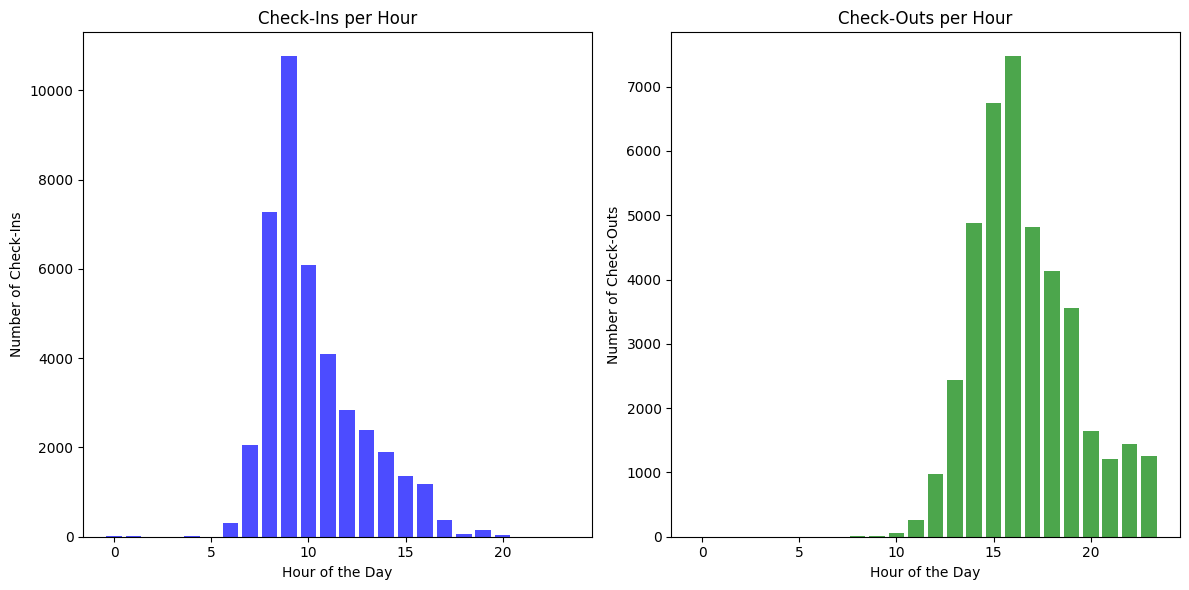

In [6]:
# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
result_df['CheckInHour'] = pd.to_datetime(result_df['CheckInTime']).dt.hour 
result_df['CheckOutHour'] = pd.to_datetime(result_df['CheckOutTime']).dt.hour 


result_df['CheckInMinutes'] = result_df['CheckInTime'].apply(time_to_minutes)
result_df['CheckOutMinutes'] = result_df['CheckOutTime'].apply(time_to_minutes)

# Count check-ins per hour
check_in_counts = result_df['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = result_df['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


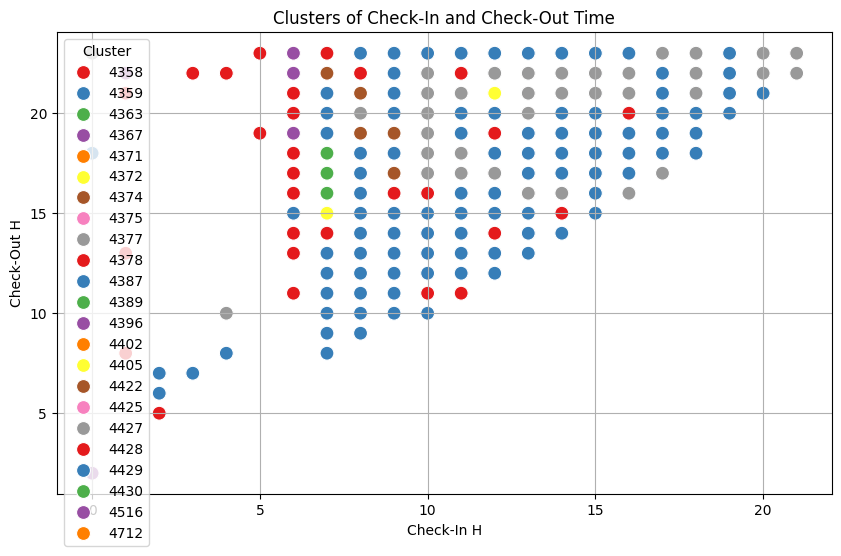

In [7]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInHour', y='CheckOutHour', hue=result_df['PlanId'], data=result_df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Time')
plt.xlabel('Check-In H')
plt.ylabel('Check-Out H')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

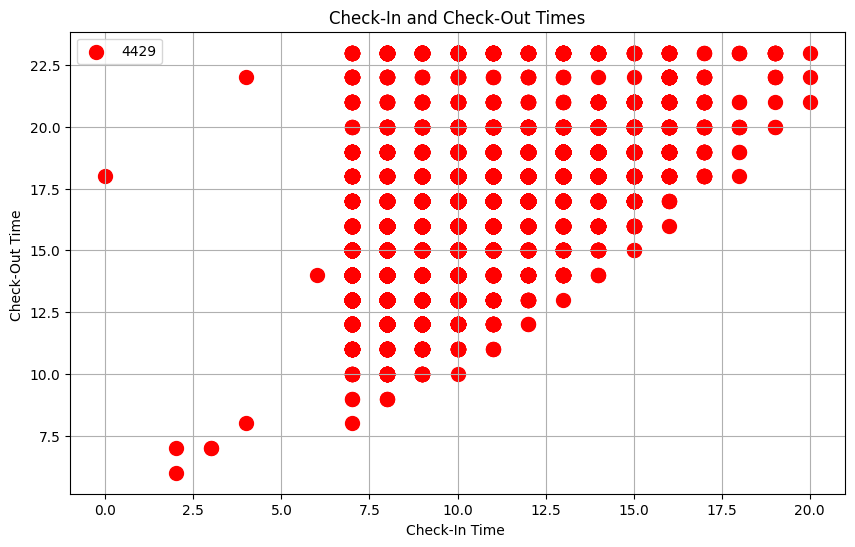

In [8]:

cluster_df = result_df[result_df['PlanId'] == 4429]   # 537 employees ,خطة حر بدون حد ادني جمعة أجازة (7 ص : 23)
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='red', label='4429', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()



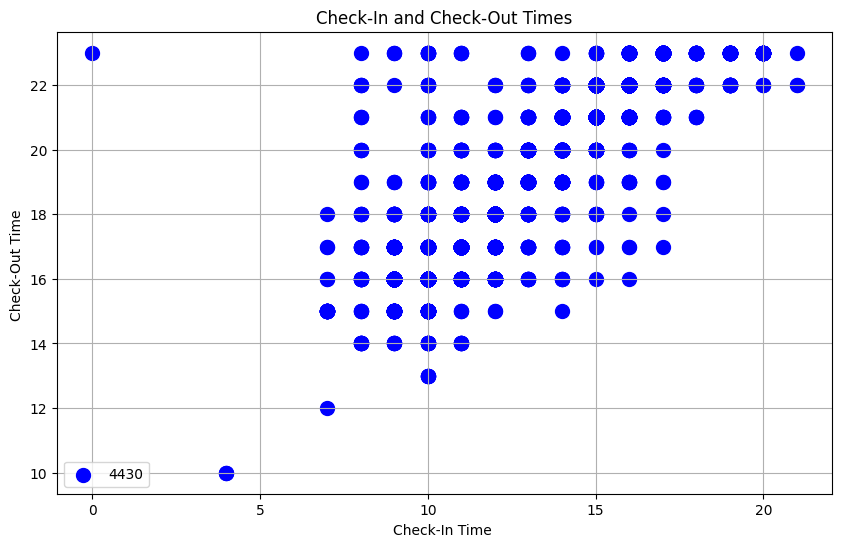

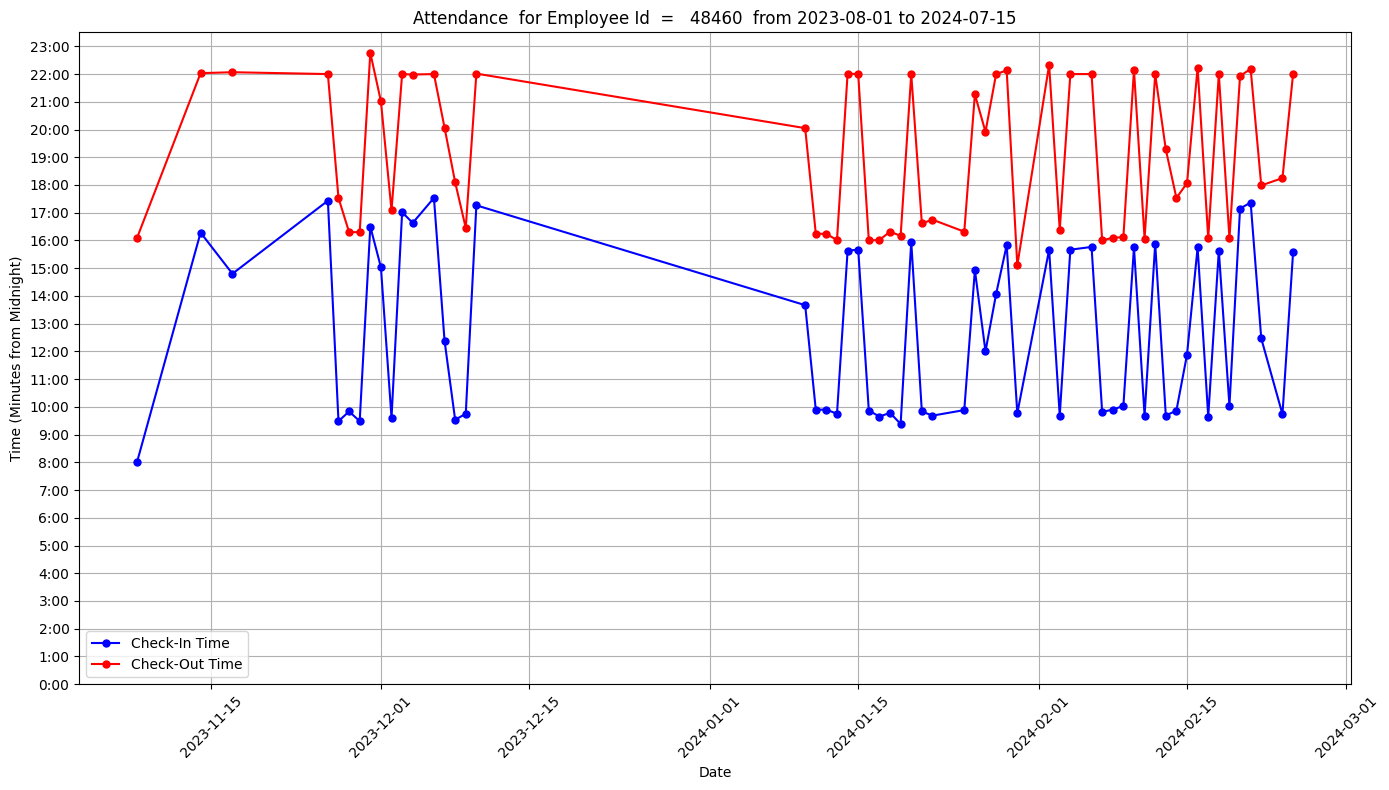

In [9]:

cluster_df = result_df[result_df['PlanId'] == 4427]  # 74 employees ,خطة حر بحد أدنى 6 س بدون راحة ثابتة من(8ص :1م),

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4430', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()





# Define the date range
start_date = '2023-08-01'
end_date = '2024-07-15'

# Filter the DataFrame for the specified date range
#filtered_df = df[(df['Transdate'] >= start_date) & (df['Transdate'] <= end_date) ]
filtered_df = cluster_df[
    (cluster_df['Transdate'] >= start_date) &
    (cluster_df['Transdate'] <= end_date) &
    (cluster_df['EmployeeId'] == 49415) #  # 47834
]
# Plot
plt.figure(figsize=(14, 8))

# Plot Check-In times
plt.plot(filtered_df['Transdate'], filtered_df['CheckInMinutes'], 'bo-', label='Check-In Time', markersize=5)

# Plot Check-Out times
plt.plot(filtered_df['Transdate'], filtered_df['CheckOutMinutes'], 'ro-', label='Check-Out Time', markersize=5)

# Customize the plot
plt.title('Attendance  for Employee Id  =   48460  from {} to {}'.format(start_date, end_date))
plt.xlabel('Date')
plt.ylabel('Time (Minutes from Midnight)')
plt.xticks(rotation=45)

# Set y-ticks for every hour in HH:00 format
y_ticks = range(0, 1381, 60)  # Every 60 minutes, up to 23:00 (1380 minutes)
y_labels = [f"{h}:00" for h in range(24)]  # 24 hours
plt.yticks(y_ticks, y_labels)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()






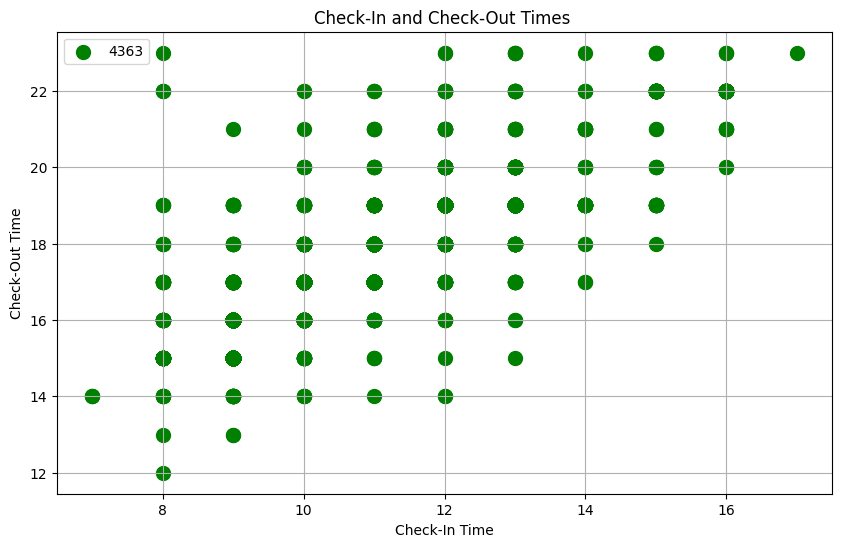

In [10]:
# Filter the DataFrame for Cluster 0
cluster_df1 = result_df[result_df['PlanId'] == 4428]  # 29 employees  ,خطة حر بحد أدنى 6.5 س الجمعة اجاز(من 8ص إلى 1م

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df1['CheckInHour'], cluster_df1['CheckOutHour'], color='green', label='4363', s=100)
plt.title('Check-In and Check-Out Times ')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

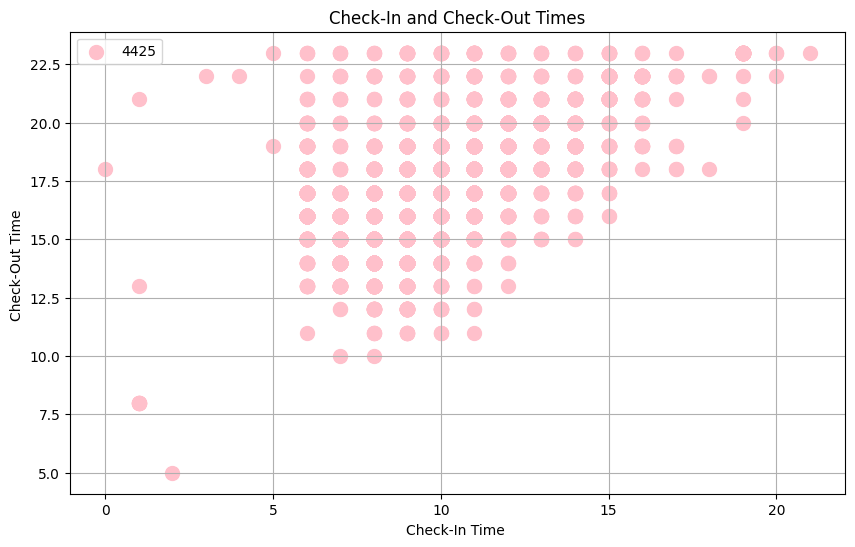

In [11]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4358] # 109 employees  "خطة حر حد ادنى 7 س جمعة اجازة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='pink', label='4425', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

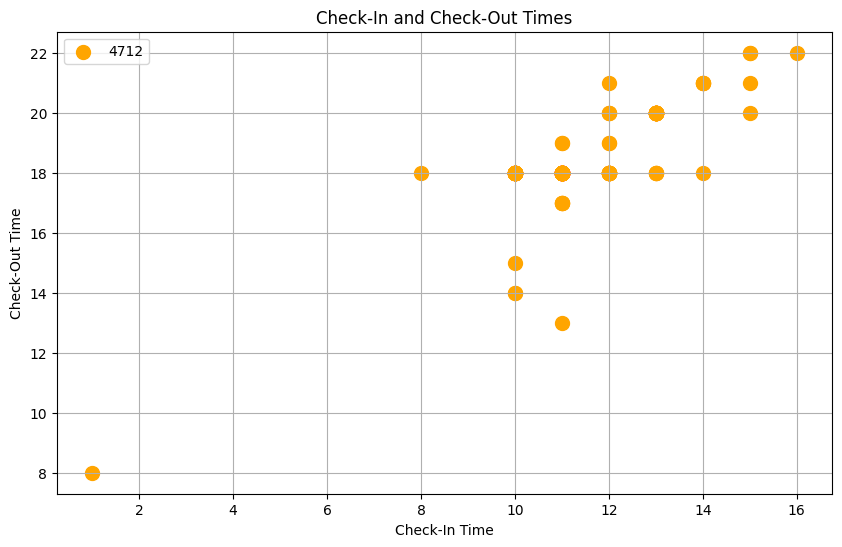

In [12]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4712] # 8 Employees ,حر بحد أدنى 6.5 بدون راحة ثابتة,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='orange', label='4712', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

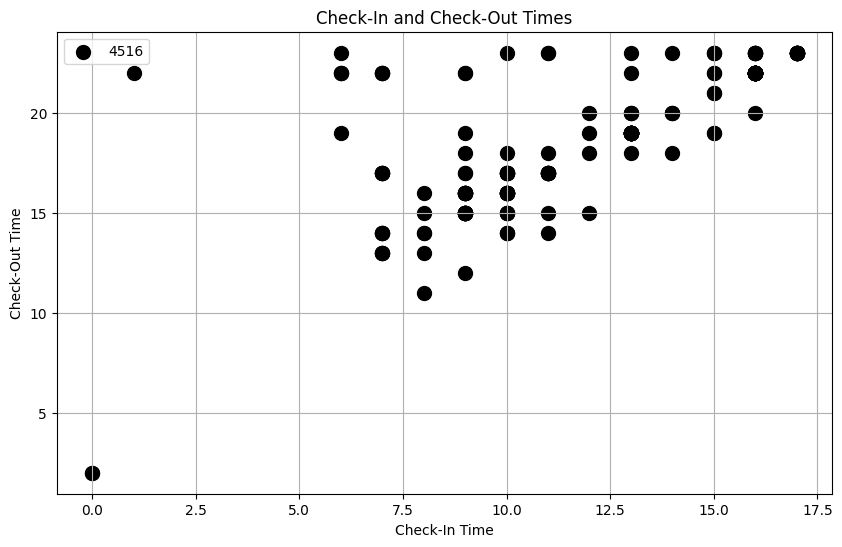

In [13]:

cluster_df = result_df[result_df['PlanId'] == 4516] #  7 Employees      ,خطة حر حد أدنى 6 س الجمعة  أجازة

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='black', label='4516', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

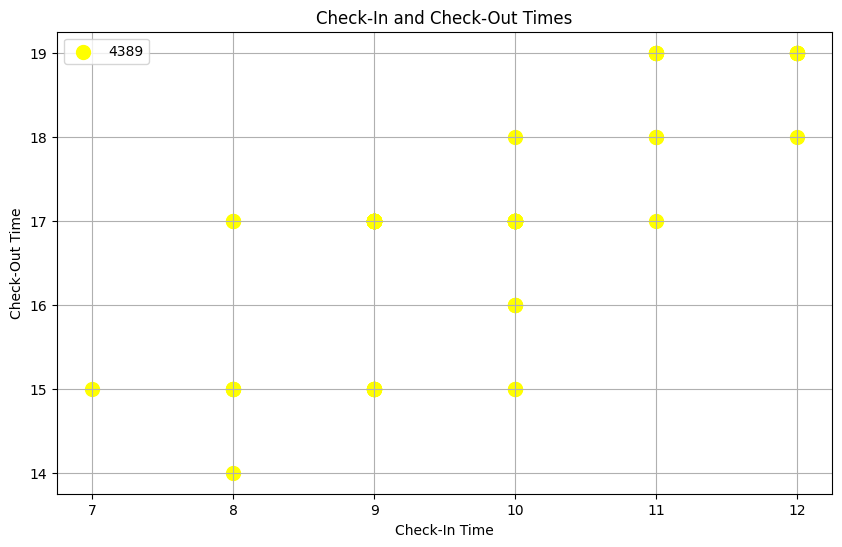

In [14]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4389] # 3 Employees  خطة روستر نمطي من 10 ل 17,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='yellow', label='4389', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

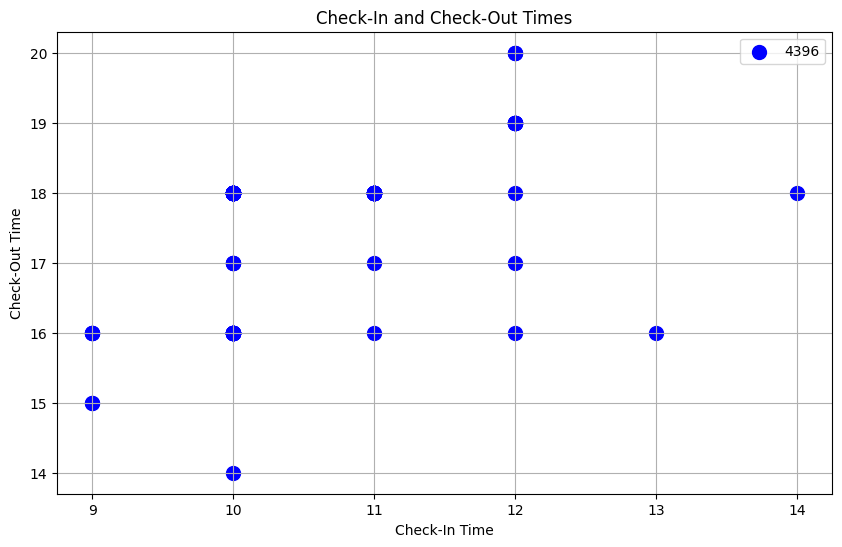

In [15]:

cluster_df = result_df[result_df['PlanId'] == 4396] # 3 Employees  خطة روستر نمطي من 11 ل 18,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4396', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
employee_count_per_Shift = result_df.groupby('PlanId')['EmployeeId'].nunique().reset_index()

# Rename columns for clarity
employee_count_per_Shift.columns = ['Shift', 'NumberOfEmployees']



# Print the result
print(employee_count_per_Shift)



    Shift  NumberOfEmployees
0    4358                109
1    4359                  4
2    4363                  3
3    4367                  1
4    4371                  1
5    4372                  1
6    4374                 12
7    4375                  2
8    4377                  1
9    4378                  1
10   4387                  1
11   4389                  3
12   4396                  3
13   4402                  1
14   4405                  3
15   4422                  1
16   4425                  2
17   4427                 74
18   4428                 29
19   4429                537
20   4430                  2
21   4516                  7
22   4712                  8


In [17]:
employees = df_plans.groupby('PlanId')['EmployeeId'].nunique().reset_index()
employees.columns = ['Cluster', 'NumberOfEmployees']
print(employees)

    Cluster  NumberOfEmployees
0      4358                143
1      4359                  4
2      4363                  4
3      4367                  1
4      4371                  1
5      4372                  2
6      4374                 14
7      4375                  2
8      4377                  1
9      4378                  1
10     4387                  1
11     4389                  3
12     4396                  3
13     4397                  1
14     4402                  1
15     4405                  4
16     4422                  1
17     4425                  2
18     4427                 98
19     4428                 42
20     4429                631
21     4430                  2
22     4516                 11
23     4712                  8


In [19]:
# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
cluster_summary = result_df.groupby('PlanId').agg({
    'CheckInHour': [ 'min', 'max'],
    'CheckOutHour': ['min', 'max']
}).reset_index()

# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster','CheckInHour_Min', 'CheckInHour_Max',
                           'CheckOutHour_Min', 'CheckOutHour_Max']

# Print the summary
print(cluster_summary)


    Cluster  CheckInHour_Min  CheckInHour_Max  CheckOutHour_Min  \
0      4358                0               21                 5   
1      4359                6               14                10   
2      4363                7               15                10   
3      4367               12               12                16   
4      4371                8               10                13   
5      4372                8               12                12   
6      4374                7               17                11   
7      4375                7               12                14   
8      4377                7               16                18   
9      4378                9               10                13   
10     4387                9               11                13   
11     4389                7               12                14   
12     4396                9               14                14   
13     4402                8               15                1